In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm

# ==========================================
# 1. CONFIGURAÇÕES & CONSTANTES
# ==========================================
DATASET_PATH = "/content/drive/MyDrive/2025/Estudos/Datasets/SBHAR/"
OUTPUT_PATH = "/content/drive/MyDrive/2025/Estudos/Datasets/SBHAR/sbhar_for_rp.npz"

# Parâmetros Físicos
FS = 50.0          # Frequência de Amostragem (50Hz)

# Parâmetros de Janelamento (2.5s / 50% Overlap)
WINDOW_SIZE = 125  # 50Hz * 2.5s = 125
STEP_SIZE = 62     # 50% Overlap

# Protocolo de Split (HAPT/SBHAR) - Sem Data Leakage
TRAIN_SUBJECTS = [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28]
VAL_SUBJECTS = [29, 30]
TEST_SUBJECTS = [2, 4, 9, 10, 12, 13, 18, 20, 24]

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ==========================================
# 2. FUNÇÃO DE EDA
# ==========================================
def run_scientific_eda(dataset_path):
    print("\n--- [PASSO 1] EXECUTANDO EDA PARA JUSTIFICATIVA DE PARÂMETROS ---")

    # Vamos carregar UM arquivo de exemplo (Exp 01, User 01)
    acc_path = os.path.join(dataset_path, "RawData", "acc_exp01_user01.txt")
    gyro_path = os.path.join(dataset_path, "RawData", "gyro_exp01_user01.txt")

    if not os.path.exists(acc_path):
        print(f"Aviso: Não encontrei {acc_path} para EDA. Pulando gráfico.")
        return

    # Carregar apenas os primeiros 1000 pontos (~20 segundos)
    acc = np.loadtxt(acc_path)[:1000, 0] # Apenas Eixo X
    gyro = np.loadtxt(gyro_path)[:1000, 0] # Apenas Eixo X

    # --- GRÁFICO 1: Domínio do Tempo (Justifica Normalização) ---
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Acelerômetro (g)', alpha=0.8)
    plt.plot(gyro, label='Giroscópio (rad/s)', alpha=0.8)
    plt.title("Justificativa 1: Discrepância de Escalas")
    plt.xlabel("Amostras (Tempo)")
    plt.ylabel("Amplitude Bruta")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- GRÁFICO 2: Domínio da Frequência (Justifica Filtro 20Hz) ---
    N = len(acc)
    yf = fft(acc)
    xf = fftfreq(N, 1/FS)[:N//2]
    magnitude = 2.0/N * np.abs(yf[0:N//2])

    plt.subplot(1, 2, 2)
    plt.plot(xf, magnitude, color='purple')
    plt.title("Justificativa 2: Análise Espectral (FFT)")
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Energia do Sinal")
    plt.axvline(x=20, color='r', linestyle='--', label='Ruído (>20Hz)')
    plt.axvline(x=0.3, color='g', linestyle='--', label='Gravidade (<0.3Hz)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [9]:
# ==========================================
# 3. FUNÇÕES DE PROCESSAMENTO
# ==========================================

def load_and_process_data(dataset_path):
    # Localizar labels.txt
    labels_path = os.path.join(dataset_path, "RawData", "labels.txt")
    if not os.path.exists(labels_path):
        # Tenta na raiz se não estiver na RawData
        labels_path = os.path.join(dataset_path, "labels.txt")

    print(f"--- [PASSO 2] CARREGANDO DADOS USANDO: {labels_path} ---")

    # CORREÇÃO: Carregar o arquivo de labels para criar o df_labels
    df_labels = pd.read_csv(labels_path, delim_whitespace=True, header=None,
                            names=['exp', 'user', 'act', 'start', 'end'])

    data_collection = []

    # Extrai os pares únicos de experimento e usuário do dataframe global de labels
    unique_experiments = df_labels[['exp', 'user']].drop_duplicates().values

    for exp_id, user_id in tqdm(unique_experiments, desc="Processando Arquivos"):
        acc_file = os.path.join(dataset_path, "RawData", f"acc_exp{exp_id:02d}_user{user_id:02d}.txt")
        gyro_file = os.path.join(dataset_path, "RawData", f"gyro_exp{exp_id:02d}_user{user_id:02d}.txt")

        try:
            # 1. Carregar (Dados Brutos)
            acc = np.loadtxt(acc_file)
            gyro = np.loadtxt(gyro_file)

            # 2. Concatenar (Sem filtro!)
            raw_signals = np.concatenate([acc, gyro], axis=1)

            # 3. Segmentar
            exp_labels = df_labels[(df_labels['exp'] == exp_id) & (df_labels['user'] == user_id)]
            for _, row in exp_labels.iterrows():
                segment = raw_signals[int(row['start']):int(row['end'])+1, :]
                data_collection.append({
                    "user_id": user_id, "activity_id": row['act'], "data": segment
                })
        except OSError:
            # Pula os arquivos caso não existam
            continue

    return data_collection


def create_windows(data_collection):
    X, y, users = [], [], []
    print("\n--- [PASSO 3] GERANDO JANELAS (SLIDING WINDOW) ---")
    for item in data_collection:
        data, label, user = item['data'], item['activity_id'], item['user_id']
        for i in range(0, data.shape[0] - WINDOW_SIZE + 1, STEP_SIZE):
            X.append(data[i : i + WINDOW_SIZE, :])
            y.append(label)
            users.append(user)

    return np.array(X, dtype=np.float32), np.array(y, dtype=int), np.array(users, dtype=int)


--- [PASSO 1] EXECUTANDO EDA PARA JUSTIFICATIVA DE PARÂMETROS ---


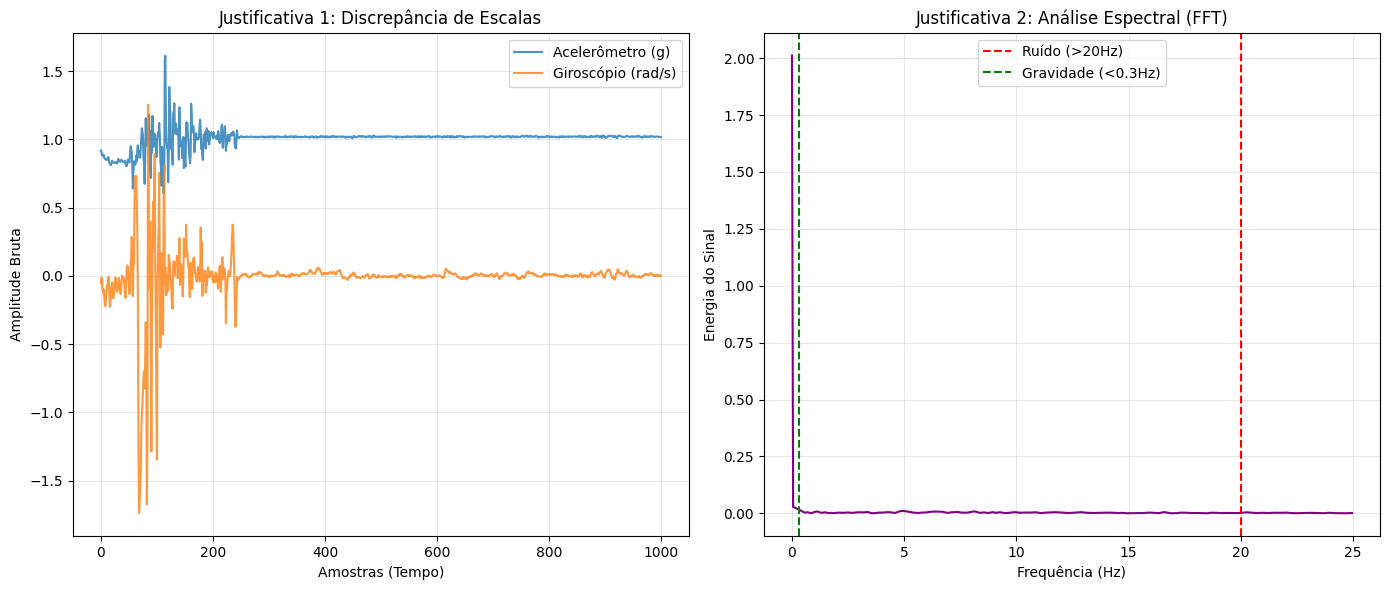

--- [PASSO 2] CARREGANDO DADOS USANDO: /content/drive/MyDrive/2025/Estudos/Datasets/SBHAR/RawData/labels.txt ---


/tmp/ipykernel_47748/779627021.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_labels = pd.read_csv(labels_path, delim_whitespace=True, header=None,
Processando Arquivos: 100%|██████████| 61/61 [01:17<00:00,  1.28s/it]



--- [PASSO 3] GERANDO JANELAS (SLIDING WINDOW) ---

--- [PASSO 4] SPLIT DOS DADOS ---

 SUCESSO! Dataset salvo em: /content/drive/MyDrive/2025/Estudos/Datasets/SBHAR/sbhar_for_rp.npz
   X_train: (7233, 125, 6)
   X_val:   (801, 125, 6)
   X_test:  (3275, 125, 6)


In [10]:
# ==========================================
# 4. EXECUÇÃO DO PIPELINE
# ==========================================

# A. EDA (Gera os gráficos primeiro)
run_scientific_eda(DATASET_PATH)

# B. Carregamento e Filtragem
data_collection = load_and_process_data(DATASET_PATH)

if len(data_collection) > 0:
    # C. Janelamento
    X, y, users = create_windows(data_collection)

    # D. Split Treino/Validação/Teste (Subject-Independent)
    print("\n--- [PASSO 4] SPLIT DOS DADOS ---")
    train_mask = np.isin(users, TRAIN_SUBJECTS)
    val_mask = np.isin(users, VAL_SUBJECTS)
    test_mask = np.isin(users, TEST_SUBJECTS)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    N_train, T, F = X_train.shape
    N_val, _, _ = X_val.shape
    N_test, _, _ = X_test.shape


    # Otimização de Memória (Float32)
    X_train = X_train.astype(np.float32)
    X_val = X_val.astype(np.float32) # NEW
    X_test = X_test.astype(np.float32)

    # F. Label Encoding
    le = LabelEncoder()
    # Fit em todas as partições garante que não falte nenhuma classe
    all_labels = np.concatenate([y_train, y_val, y_test])
    le.fit(all_labels)

    y_train = le.transform(y_train)
    y_val = le.transform(y_val)
    y_test = le.transform(y_test)

    # G. Salvamento (.npz)
    np.savez_compressed(
        OUTPUT_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        classes=le.classes_
    )

    print(f"\n SUCESSO! Dataset salvo em: {OUTPUT_PATH}")
    print(f"   X_train: {X_train.shape}")
    print(f"   X_val:   {X_val.shape}")
    print(f"   X_test:  {X_test.shape}")